<a href="https://colab.research.google.com/github/AliRaddman/divar-ml-project/blob/main/notebooks/work/descriptive_ben.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<div dir="rtl" style="text-align: right;">

# آمار توصیفی دیتاست آگهی‌های املاک دیوار

در این نوت‌بوک از خروجی نهایی preprocessing استفاده می‌کنیم:

<code>cleaned_step2_benyamin_v2.parquet</code>

این فایل شامل ستون‌های تمیزشده، ستون‌های قیمتی جدید، فلگ‌های اعتبارسنجی و متغیرهای کمکی برای تحلیل فروش، اجاره، قیمت واحد و تحلیل مکانی است.

در مرحله‌ی اول، دیتاست را از Google Drive می‌خوانیم و چند بررسی اولیه انجام می‌دهیم تا مطمئن شویم فایل درست load شده است.

</div>

In [2]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


<div dir="rtl" style="text-align: right;">

## آماده‌سازی کتابخانه‌ها و مسیر فایل

در این بخش کتابخانه‌های اصلی مورد نیاز برای آمار توصیفی را import می‌کنیم.

فعلاً فقط از <code>pandas</code>، <code>numpy</code> و ابزارهای پایه‌ی نمایش استفاده می‌کنیم.

در مراحل بعدی برای رسم نمودارها از <code>matplotlib</code> و <code>seaborn</code> استفاده خواهیم کرد.

</div>

In [3]:
import pandas as pd
import numpy as np
from pathlib import Path

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", "{:,.2f}".format)

DATA_PATH = Path("/content/drive/MyDrive/divar_project/cleaned_step2_benyamin_v2.parquet")

print("File exists:", DATA_PATH.exists())
print("File path:", DATA_PATH)

File exists: True
File path: /content/drive/MyDrive/divar_project/cleaned_step2_benyamin_v2.parquet


<div dir="rtl" style="text-align: right;">

## خواندن دیتاست نهایی preprocessing

در این بخش فایل parquet نهایی را می‌خوانیم و در متغیر <code>df</code> ذخیره می‌کنیم.

انتظار داریم دیتاست حدوداً شامل ۹۹۹,۹۴۳ ردیف و ۷۸ ستون باشد.

</div>

In [4]:
df = pd.read_parquet(DATA_PATH)

print("Shape:", df.shape)
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Shape: (999943, 80)
Number of rows: 999943
Number of columns: 80


<div dir="rtl" style="text-align: right;">

## بررسی اولیه ستون‌ها و چند ردیف نمونه

برای اطمینان از اینکه دیتاست درست load شده، چند ردیف ابتدایی و نام ستون‌ها را بررسی می‌کنیم.

همچنین چند ستون کلیدی preprocessing را چک می‌کنیم تا مطمئن شویم نسخه‌ی درست فایل را باز کرده‌ایم.

</div>

In [5]:
important_columns = [
    "transaction_type",
    "price_value_pos",
    "rent_value_pos",
    "credit_value_pos",
    "building_size_pos",
    "land_size_pos",
    "area_for_unit_price",
    "monthly_rent_equivalent",
    "sale_price_per_m2",
    "target_price",
    "target_price_type",
    "target_price_per_m2",
    "has_geo",
    "is_valid_geo_basic",
    "is_valid_for_price_analysis"
]

missing_important_columns = [col for col in important_columns if col not in df.columns]

print("Missing important columns:", missing_important_columns)
print("\nTransaction type counts:")
print(df["transaction_type"].value_counts(dropna=False))

display(df.head())

Missing important columns: []

Transaction type counts:
transaction_type
sell              597552
rent              353092
temporary_rent     29897
other              19402
Name: count, dtype: int64


,cat2_slug,cat3_slug,city_slug,neighborhood_slug,created_at_month,user_type,description,title,rent_mode,rent_value,rent_type,price_mode,price_value,credit_mode,credit_value,rent_credit_transform,transformable_price,transformable_credit,transformed_credit,transformable_rent,transformed_rent,land_size,building_size,deed_type,has_business_deed,floor,rooms_count,total_floors_count,unit_per_floor,has_balcony,has_elevator,has_warehouse,has_parking,construction_year,is_rebuilt,has_warm_water_provider,has_heating_system,has_cooling_system,has_restroom,has_security_guard,has_barbecue,building_direction,has_pool,has_jacuzzi,has_sauna,floor_material,property_type,regular_person_capacity,location_latitude,location_longitude,location_radius,created_at_shamsi,created_at_shamsi_readable,construction_year_was_missing,construction_year_imputed,transaction_type,price_value_pos,rent_value_pos,credit_value_pos,building_size_pos,land_size_pos,area_for_unit_price,monthly_rent_equivalent,credit_equivalent,sale_price_per_m2,monthly_rent_equivalent_per_m2,credit_equivalent_per_m2,target_price,target_price_type,target_price_per_m2,is_valid_area_basic,is_valid_sale_price_basic,is_valid_rent_value_basic,is_valid_credit_value_basic,is_valid_target_price_basic,is_valid_area_q01_q99_by_cat3,is_valid_target_price_per_m2_q01_q99_by_cat3,is_valid_for_price_analysis,has_geo,is_valid_geo_basic
0,temporary-rent,villa,karaj,mehrshahr,2024-08-01,مشاور املاک,۵۰۰متر\n۲۰۰متر بنا دوبلکس\n۳خواب\nاستخر آبگرم ...,باغ ویلا اجاره روزانه استخر داخل لشکرآباد سهیلیه,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,<NA>,NaN,NaN,NaN,NaN,NaN,500.00,NaN,<NA>,NaN,3.00,NaN,NaN,False,False,False,False,NaN,False,NaN,NaN,NaN,NaN,False,False,NaN,False,False,False,NaN,NaN,4.00,35.81,50.94,500.00,1403-05,مرداد 1403,True,"1,395.00",temporary_rent,NaN,NaN,NaN,500.00,NaN,500.00,NaN,NaN,NaN,NaN,NaN,NaN,not_defined,NaN,True,True,True,True,True,True,<NA>,False,True,True
1,residential-sell,apartment-sell,tehran,gholhak,2024-05-01,مشاور املاک,دسترسی عالی به مترو و شریعتی \nمشاعات تمیز \nب...,۶۰ متر قلهک فول امکانات,NaN,NaN,NaN,مقطوع,"8,500,000,000.00",NaN,NaN,<NA>,<NA>,NaN,NaN,NaN,NaN,NaN,60.00,NaN,<NA>,3.00,1.00,NaN,NaN,False,True,True,True,"1,384.00",False,NaN,NaN,NaN,NaN,False,False,NaN,False,False,False,NaN,NaN,NaN,NaN,NaN,500.00,1403-02,اردیبهشت 1403,False,"1,384.00",sell,"8,500,000,000.00",NaN,NaN,60.00,NaN,60.00,NaN,NaN,"141,666,666.67",NaN,NaN,"8,500,000,000.00",sale_total_price,"141,666,666.67",True,True,True,True,True,True,True,True,False,<NA>
2,residential-rent,apartment-rent,tehran,tohid,2024-10-01,NaN,تخلیه پایان ماه,آپارتمان ۳ خوابه ۱۳۲ متر,مقطوع,"26,000,000.00",NaN,NaN,NaN,مقطوع,"750,000,000.00",False,False,"750,000,000.00",NaN,"26,000,000.00",NaN,NaN,132.00,NaN,<NA>,3.00,3.00,NaN,NaN,False,True,True,True,"1,401.00",False,NaN,NaN,NaN,NaN,False,False,NaN,False,False,False,NaN,NaN,NaN,35.70,51.37,NaN,1403-07,مهر 1403,False,"1,401.00",rent,NaN,"26,000,000.00","750,000,000.00",132.00,NaN,132.00,"48,500,000.00","1,616,666,666.67",NaN,"367,424.24","12,247,474.75","48,500,000.00",monthly_rent_equivalent,"367,424.24",True,True,True,True,True,True,True,True,True,True
3,commercial-rent,office-rent,tehran,elahiyeh,2024-06-01,NaN,فرشته تاپ لوکیشن\n۹۰ متر موقعیت اداری\nیک اتاق...,فرشته ۹۰ متر دفتر کار مدرن موقعیت اداری,مقطوع,"95,000,000.00",NaN,NaN,NaN,مقطوع,"950,000,000.00",False,False,"950,000,000.00",NaN,"95,000,000.00",NaN,NaN,90.00,NaN,<NA>,4.00,1.00,NaN,NaN,False,True,False,True,"1,400.00",False,NaN,NaN,NaN,NaN,False,False,NaN,False,False,False,NaN,NaN,NaN,NaN,NaN,NaN,1403-03,خرداد 1403,False,"1,400.00",rent,NaN,"95,000,000.00","950,000,000.00",90.00,NaN,90.00,"123,500,000.00","4,116,666,666.67",NaN,"1,372,222.22","45,740,740.74","123,500,000.00",monthly_rent_equivalent,"1,372,222.22",True,True,True,True,True,True,True,True,False,<NA>
4,residential-sell,apartment-sell,mashhad,emamreza,2024-05-01,مشاور املاک,هلدینگ ساختمانی اکبری\n\nهمراه شما هستیم برای ...,۱۱۵ متری/شمالی رو به آفتاب/اکبری,NaN,NaN,NaN,مقط

<div dir="rtl" style="text-align: right;">

## خلاصه‌ی اولیه دیتاست

در این بخش تعداد داده‌های missing در ستون‌های مهم را بررسی می‌کنیم.

این بررسی کمک می‌کند قبل از شروع آمار توصیفی بدانیم کدام ستون‌ها برای تحلیل مستقیم مناسب هستند و کدام ستون‌ها نیاز به فیلتر دارند.

</div>

In [6]:
summary_cols = [
    "transaction_type",
    "cat2_slug",
    "cat3_slug",
    "price_value",
    "rent_value",
    "credit_value",
    "building_size",
    "land_size",
    "construction_year",
    "target_price",
    "target_price_per_m2",
    "has_geo",
    "is_valid_for_price_analysis"
]

available_summary_cols = [col for col in summary_cols if col in df.columns]

missing_summary = df[available_summary_cols].isna().sum().sort_values(ascending=False)

print("Available summary columns:", available_summary_cols)
print("\nMissing values in selected columns:")
print(missing_summary)

Available summary columns: ['transaction_type', 'cat2_slug', 'cat3_slug', 'price_value', 'rent_value', 'credit_value', 'building_size', 'land_size', 'construction_year', 'target_price', 'target_price_per_m2', 'has_geo', 'is_valid_for_price_analysis']

Missing values in selected columns:
land_size                      813553
rent_value                     648653
credit_value                   647880
price_value                    431613
construction_year              184164
target_price_per_m2             82609
target_price                    82609
transaction_type                    0
cat3_slug                           0
cat2_slug                           0
building_size                       0
has_geo                             0
is_valid_for_price_analysis         0
dtype: int64


<div dir="rtl" style="text-align: right;">

## سؤال ۴: توزیع قیمت فروش بر اساس دسته‌بندی سطح سه

در این بخش فقط آگهی‌های فروش بررسی می‌شوند.

برای تحلیل، از ستون <code>price_value_pos</code> استفاده می‌کنیم، چون این ستون نسخه‌ی مثبت و معتبر قیمت فروش است.

همچنین فقط رکوردهایی را نگه می‌داریم که برای تحلیل قیمت معتبر شناخته شده‌اند:

<code>is_valid_for_price_analysis == True</code>

برای جلوگیری از شلوغ شدن نمودار، فقط ۱۰ دسته‌ی پرتکرار سطح سه در آگهی‌های فروش رسم می‌شوند.

</div>

In [7]:
sell_price_df = df[
    (df["transaction_type"] == "sell") &
    (df["is_valid_for_price_analysis"] == True) &
    (df["price_value_pos"].notna()) &
    (df["price_value_pos"] > 0)
].copy()

sell_price_df["cat3_slug"] = sell_price_df["cat3_slug"].astype(str)
sell_price_df["price_billion_toman"] = sell_price_df["price_value_pos"] / 1_000_000_000

top_10_sell_cat3 = (
    sell_price_df["cat3_slug"]
    .value_counts()
    .head(10)
    .index
)

sell_price_top10 = sell_price_df[
    sell_price_df["cat3_slug"].isin(top_10_sell_cat3)
].copy()

print("Number of valid sell ads:", len(sell_price_df))
print("Top 10 sell cat3_slug categories:")

display(
    sell_price_df["cat3_slug"]
    .value_counts()
    .head(10)
    .reset_index()
    .rename(columns={"cat3_slug": "cat3_slug", "count": "ads_count"})
)

print("Categories used in plot:")
print(sorted(sell_price_top10["cat3_slug"].unique()))

Number of valid sell ads: 538315
Top 10 sell cat3_slug categories:


,cat3_slug,ads_count
0,apartment-sell,290983
1,house-villa-sell,113508
2,plot-old,105725
3,shop-sell,16597
4,industry-agriculture-business-sell,7272
5,office-sell,4230


Categories used in plot:
['apartment-sell', 'house-villa-sell', 'industry-agriculture-business-sell', 'office-sell', 'plot-old', 'shop-sell']


<div dir="rtl" style="text-align: right;">

## آماده‌سازی کتابخانه‌های رسم نمودار

برای رسم نمودارها از دو کتابخانه استفاده می‌کنیم:

<ul>
  <li><code>matplotlib.pyplot</code> با نام کوتاه <code>plt</code></li>
  <li><code>seaborn</code> با نام کوتاه <code>sns</code></li>
</ul>

خطای <code>NameError: name 'plt' is not defined</code> یعنی کتابخانه‌ی <code>matplotlib.pyplot</code> هنوز در نوت‌بوک import نشده یا سلول import آن اجرا نشده است.

</div>

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

print("Plotting libraries imported successfully.")

Plotting libraries imported successfully.


<div dir="rtl" style="text-align: right;">

## نمودار توزیع قیمت فروش

در این نمودار، توزیع قیمت فروش برای ۱۰ دسته‌ی پرتکرار سطح سه نمایش داده می‌شود.

قیمت‌ها به میلیارد تومان تبدیل شده‌اند تا خوانایی بهتر شود.

از آن‌جایی که قیمت ملک معمولاً دارای مقدارهای بسیار بزرگ و outlierهای زیاد است، محور عمودی به صورت لگاریتمی رسم می‌شود. این کار باعث می‌شود تفاوت بین دسته‌ها بهتر دیده شود.

</div>

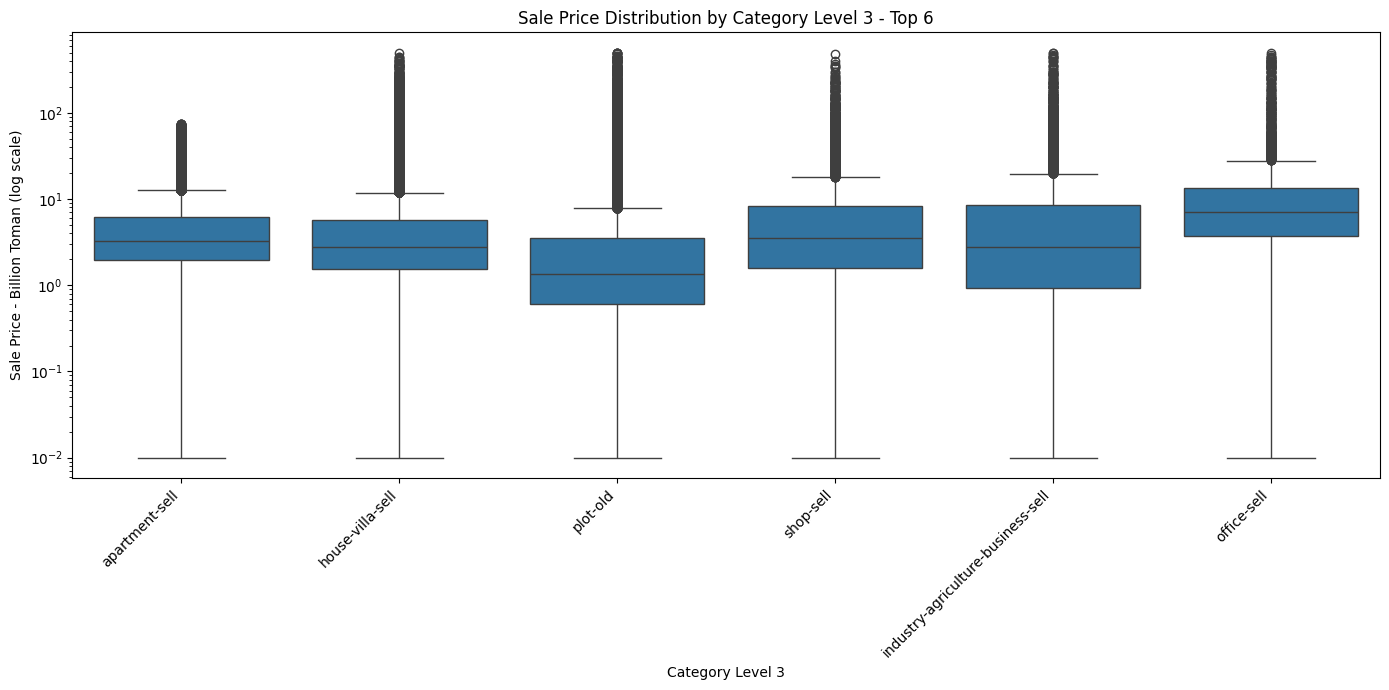

In [11]:
plt.figure(figsize=(14, 7))

sns.boxplot(
    data=sell_price_top10,
    x="cat3_slug",
    y="price_billion_toman",
    order=top_10_sell_cat3
)

plt.yscale("log")

plt.xticks(rotation=45, ha="right")
plt.title(f"Sale Price Distribution by Category Level 3 - Top {len(top_10_sell_cat3)}")
plt.xlabel("Category Level 3")
plt.ylabel("Sale Price - Billion Toman (log scale)")

plt.tight_layout()
plt.show()

تحلیل اوتلایر های پایین داریم یا نه

In [13]:
def count_boxplot_outliers_by_group(data, group_col, value_col):
    rows = []

    for group, group_data in data.groupby(group_col):
        values = group_data[value_col].dropna()

        q1 = values.quantile(0.25)
        q3 = values.quantile(0.75)
        iqr = q3 - q1

        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr

        lower_outliers = (values < lower_bound).sum()
        upper_outliers = (values > upper_bound).sum()

        rows.append({
            group_col: group,
            "q1": q1,
            "median": values.median(),
            "q3": q3,
            "lower_bound": lower_bound,
            "upper_bound": upper_bound,
            "lower_outliers": lower_outliers,
            "upper_outliers": upper_outliers
        })

    return pd.DataFrame(rows).sort_values("upper_outliers", ascending=False)


outlier_check = count_boxplot_outliers_by_group(
    sell_price_top10,
    "cat3_slug",
    "price_billion_toman"
)

display(outlier_check)

,cat3_slug,q1,median,q3,lower_bound,upper_bound,lower_outliers,upper_outliers
0,apartment-sell,1.95,3.30,6.20,-4.44,12.58,0,24470
4,plot-old,0.60,1.35,3.50,-3.75,7.85,0,13268
1,house-villa-sell,1.55,2.80,5.70,-4.68,11.93,0,11204
5,shop-sell,1.60,3.50,8.20,-8.30,18.10,0,1642
2,industry-agriculture-business-sell,0.93,2.75,8.50,-10.43,19.86,0,948
3,office-sell,3.77,7.00,13.50,-10.83,28.10,0,374


<div dir="rtl" style="text-align: right;">

## خلاصه آماری قیمت فروش در دسته‌بندی‌های سطح سه

برای تفسیر دقیق‌تر نمودار، در این بخش برای هر دسته‌ی سطح سه چند شاخص آماری محاسبه می‌کنیم:

<ul>
  <li>تعداد آگهی‌ها</li>
  <li>میانه قیمت فروش</li>
  <li>میانگین قیمت فروش</li>
  <li>چارک اول و سوم</li>
  <li>کمینه و بیشینه قیمت</li>
</ul>

همه‌ی قیمت‌ها در این جدول بر حسب میلیارد تومان هستند.

</div>

In [12]:
sale_price_summary = (
    sell_price_top10
    .groupby("cat3_slug")["price_billion_toman"]
    .agg(
        ads_count="count",
        min_price="min",
        q1=lambda x: x.quantile(0.25),
        median_price="median",
        mean_price="mean",
        q3=lambda x: x.quantile(0.75),
        max_price="max"
    )
    .reset_index()
)

sale_price_summary = sale_price_summary.sort_values(
    "median_price",
    ascending=False
)

display(sale_price_summary)

,cat3_slug,ads_count,min_price,q1,median_price,mean_price,q3,max_price
3,office-sell,4230,0.01,3.77,7.00,16.74,13.50,500.00
5,shop-sell,16597,0.01,1.60,3.50,8.56,8.20,480.00
0,apartment-sell,290983,0.01,1.95,3.30,5.37,6.20,75.00
1,house-villa-sell,113508,0.01,1.55,2.80,5.97,5.70,500.00
2,industry-agriculture-business-sell,7272,0.01,0.93,2.75,11.87,8.50,500.00
4,plot-old,105725,0.01,0.60,1.35,5.34,3.50,500.00


<div dir="rtl" style="text-align: right;">

## تحلیل نهایی سؤال ۴

در این بخش توزیع قیمت فروش آگهی‌ها بر اساس دسته‌بندی سطح سه بررسی شد. برای این تحلیل فقط آگهی‌های فروش معتبر انتخاب شدند و قیمت‌ها بر حسب میلیارد تومان نمایش داده شدند.

بر اساس جدول خلاصه آماری، بیشترین تعداد آگهی فروش مربوط به دسته‌ی <code>apartment-sell</code> است. این دسته با بیش از ۲۹۰ هزار آگهی، بخش اصلی بازار فروش در دیتاست را تشکیل می‌دهد. بعد از آن، دسته‌های <code>house-villa-sell</code> و <code>plot-old</code> تعداد آگهی‌های بالایی دارند.

از نظر میانه قیمت، دسته‌ی <code>office-sell</code> بالاترین مقدار را دارد. میانه قیمت در این دسته حدود ۷ میلیارد تومان است، که نشان می‌دهد آگهی‌های فروش دفتر کار معمولاً قیمت بالاتری نسبت به بسیاری از دسته‌های دیگر دارند. بعد از آن، <code>shop-sell</code> و <code>apartment-sell</code> قرار می‌گیرند.

در مقابل، دسته‌ی <code>plot-old</code> پایین‌ترین میانه قیمت را دارد. این موضوع می‌تواند به دلیل تنوع زیاد زمین‌ها، موقعیت مکانی متفاوت، یا وجود آگهی‌های ارزان‌تر در شهرها و مناطق مختلف باشد.

نکته‌ی مهم دیگر این است که در همه‌ی دسته‌ها، مقدار میانگین از میانه بیشتر است. این اختلاف نشان می‌دهد توزیع قیمت فروش راست‌چوله است؛ یعنی بیشتر آگهی‌ها در بازه‌های قیمتی پایین‌تر و میانی قرار دارند، اما تعدادی آگهی با قیمت‌های بسیار بالا باعث افزایش میانگین شده‌اند.

به همین دلیل در نمودار boxplot از محور لگاریتمی استفاده شد. محور لگاریتمی باعث شد بدنه‌ی اصلی داده‌ها بهتر دیده شود و مقایسه‌ی میانه و چارک‌های قیمت بین دسته‌های مختلف خواناتر باشد. با این حال، وجود تعداد زیادی outlier در بالای نمودار نشان می‌دهد بازار املاک از نظر قیمت پراکندگی زیادی دارد.

در مجموع، می‌توان گفت نوع ملک نقش مهمی در سطح قیمت فروش دارد. دفتر کار و مغازه معمولاً قیمت میانه بالاتری دارند، در حالی که زمین‌های قدیمی یا کلنگی پراکندگی بیشتری نشان می‌دهند و میانه قیمت پایین‌تری دارند.

</div>

<div dir="rtl" style="text-align: right;">

## سؤال ۵: بررسی داده‌های مکانی برای رسم Heatmap

در این بخش می‌خواهیم تراکم مکانی آگهی‌ها را روی نقشه بررسی کنیم.

برای رسم heatmap از ستون‌های طول و عرض جغرافیایی استفاده می‌کنیم:

<ul>
  <li><code>location_latitude</code>: عرض جغرافیایی</li>
  <li><code>location_longitude</code>: طول جغرافیایی</li>
</ul>

برای اینکه نقشه دقیق‌تر باشد، فقط رکوردهایی را نگه می‌داریم که داده‌ی مکانی معتبر دارند:

<ul>
  <li><code>has_geo == True</code></li>
  <li><code>is_valid_geo_basic == True</code></li>
  <li>طول و عرض جغرافیایی مقدار missing نداشته باشند</li>
</ul>

در این مرحله هنوز نقشه رسم نمی‌کنیم؛ فقط داده‌های مکانی معتبر را آماده و بررسی می‌کنیم.

</div>

In [14]:
geo_cols = [
    "city_slug",
    "neighborhood_slug",
    "location_latitude",
    "location_longitude",
    "location_radius",
    "has_geo",
    "is_valid_geo_basic",
    "transaction_type"
]

available_geo_cols = [col for col in geo_cols if col in df.columns]
missing_geo_cols = [col for col in geo_cols if col not in df.columns]

print("Available geo columns:")
print(available_geo_cols)

print("\nMissing geo columns:")
print(missing_geo_cols)

geo_df = df[
    (df["has_geo"] == True) &
    (df["is_valid_geo_basic"] == True) &
    (df["location_latitude"].notna()) &
    (df["location_longitude"].notna())
].copy()

print("\nOriginal dataset shape:", df.shape)
print("Valid geo dataset shape:", geo_df.shape)
print("Valid geo percentage:", round(len(geo_df) / len(df) * 100, 2), "%")

print("\nLatitude range:")
print(geo_df["location_latitude"].min(), "to", geo_df["location_latitude"].max())

print("\nLongitude range:")
print(geo_df["location_longitude"].min(), "to", geo_df["location_longitude"].max())

print("\nTop 10 cities by number of geo-tagged ads:")
display(
    geo_df["city_slug"]
    .value_counts()
    .head(10)
    .reset_index()
    .rename(columns={"city_slug": "city_slug", "count": "ads_count"})
)

print("\nTop 10 neighborhoods by number of geo-tagged ads:")
display(
    geo_df["neighborhood_slug"]
    .value_counts()
    .head(10)
    .reset_index()
    .rename(columns={"neighborhood_slug": "neighborhood_slug", "count": "ads_count"})
)

Available geo columns:
['city_slug', 'neighborhood_slug', 'location_latitude', 'location_longitude', 'location_radius', 'has_geo', 'is_valid_geo_basic', 'transaction_type']

Missing geo columns:
[]

Original dataset shape: (999943, 80)
Valid geo dataset shape: (655576, 80)
Valid geo percentage: 65.56 %

Latitude range:
24.154272079467773 to 39.808536529541016

Longitude range:
43.1356201171875 to 62.84333038330078

Top 10 cities by number of geo-tagged ads:


,city_slug,ads_count
0,tehran,143080
1,mashhad,37351
2,karaj,36037
3,isfahan,24770
4,shiraz,19947
5,tabriz,16875
6,andisheh-new-town,15405
7,rasht,12352
8,kermanshah,10849
9,qom,9403



Top 10 neighborhoods by number of geo-tagged ads:


,neighborhood_slug,ads_count
0,poonak,3817
1,elahiyehblvd,3086
2,west-tehranpars,2991
3,ghasemabad,2911
4,saadat-abad,2836
5,marlik,2612
6,jeyhoun,2555
7,sarsabil,2465
8,gohardasht,2437
9,chitgar-lake,2269


<div dir="rtl" style="text-align: right;">

## رسم Heatmap مکانی آگهی‌ها

برای رسم نقشه‌ی حرارتی، از داده‌های مکانی معتبر استفاده می‌کنیم.

چون تعداد رکوردهای دارای مختصات زیاد است، مختصات جغرافیایی را تا دو رقم اعشار گرد می‌کنیم و سپس تعداد آگهی‌ها در هر نقطه‌ی گرد‌شده را به عنوان وزن محاسبه می‌کنیم.

این کار باعث می‌شود نقشه سبک‌تر اجرا شود و در عین حال تراکم کلی آگهی‌ها حفظ شود.

در این نقشه، نقاط پررنگ‌تر نشان‌دهنده‌ی تراکم بالاتر آگهی‌ها هستند.

</div>

In [15]:
import folium
from folium.plugins import HeatMap

# مرکز تقریبی ایران برای شروع نمایش نقشه
iran_center = [
    geo_df["location_latitude"].mean(),
    geo_df["location_longitude"].mean()
]

# کاهش حجم داده برای heatmap با گرد کردن مختصات
geo_heatmap_data = (
    geo_df
    .assign(
        lat_round=geo_df["location_latitude"].round(2),
        lon_round=geo_df["location_longitude"].round(2)
    )
    .groupby(["lat_round", "lon_round"])
    .size()
    .reset_index(name="weight")
)

print("Original valid geo rows:", len(geo_df))
print("Aggregated heatmap points:", len(geo_heatmap_data))

display(
    geo_heatmap_data
    .sort_values("weight", ascending=False)
    .head(10)
)

# ساخت نقشه
m = folium.Map(
    location=iran_center,
    zoom_start=5,
    tiles="OpenStreetMap"
)

# افزودن heatmap
heat_data = geo_heatmap_data[["lat_round", "lon_round", "weight"]].values.tolist()

HeatMap(
    heat_data,
    radius=12,
    blur=18,
    max_zoom=10
).add_to(m)

m

Original valid geo rows: 655576
Aggregated heatmap points: 58584


,lat_round,lon_round,weight
31393,35.68,51.02,4654
31530,35.69,51.02,2765
40908,36.48,52.12,1959
31562,35.69,51.36,1871
31271,35.67,51.02,1677
31392,35.68,51.01,1655
31563,35.69,51.37,1641
42645,36.57,52.03,1342
31701,35.70,51.37,1217
32165,35.73,51.30,1178


<div dir="rtl" style="text-align: right;">

## بررسی مناطق پرتراکم بر اساس شهر و محله

برای پاسخ دقیق‌تر به این بخش از سؤال که «تراکم آگهی‌ها در کدام منطقه بیشتر است؟»، فقط مشاهده‌ی نقشه کافی نیست.

بنابراین تعداد آگهی‌ها را بر اساس ترکیب شهر و محله محاسبه می‌کنیم تا پرتراکم‌ترین مناطق به صورت عددی مشخص شوند.

</div>

In [16]:
top_city_neighborhoods = (
    geo_df
    .dropna(subset=["city_slug", "neighborhood_slug"])
    .groupby(["city_slug", "neighborhood_slug"])
    .size()
    .reset_index(name="ads_count")
    .sort_values("ads_count", ascending=False)
)

display(top_city_neighborhoods.head(20))

/tmp/ipykernel_442/501744697.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["city_slug", "neighborhood_slug"])


,city_slug,neighborhood_slug,ads_count
471250,tehran,poonak,3817
298463,mashhad,elahiyehblvd,3086
471603,tehran,west-tehranpars,2991
298549,mashhad,ghasemabad,2911
471300,tehran,saadat-abad,2836
215685,karaj,marlik,2612
470935,tehran,jeyhoun,2555
471342,tehran,sarsabil,2465
215399,karaj,gohardasht,2437
470652,tehran,chitgar-lake,2269


<div dir="rtl" style="text-align: right;">

## تحلیل نهایی سؤال ۵

در این بخش تراکم مکانی آگهی‌های املاک بررسی شد. برای این تحلیل فقط آگهی‌هایی استفاده شدند که مختصات جغرافیایی معتبر داشتند؛ یعنی مقدارهای <code>has_geo</code> و <code>is_valid_geo_basic</code> برای آن‌ها درست بود و ستون‌های طول و عرض جغرافیایی مقدار missing نداشتند.

از کل دیتاست، تعداد ۶۵۵,۵۷۶ آگهی دارای مختصات معتبر بودند که حدود ۶۵.۵۶ درصد کل داده‌ها را تشکیل می‌دهد. این مقدار نشان می‌دهد بخش قابل توجهی از آگهی‌ها برای تحلیل مکانی قابل استفاده هستند.

برای رسم heatmap، مختصات جغرافیایی تا دو رقم اعشار گرد شدند و سپس تعداد آگهی‌ها در هر نقطه‌ی مکانی به عنوان وزن محاسبه شد. با این کار تعداد نقاط از بیش از ۶۵۵ هزار رکورد به ۵۸,۵۸۴ نقطه‌ی تجمیع‌شده کاهش پیدا کرد. این روش باعث شد نقشه سبک‌تر شود و در عین حال الگوی کلی تراکم آگهی‌ها حفظ شود.

بر اساس جدول شهرها، بیشترین تعداد آگهی مکانی مربوط به شهر تهران است. بعد از تهران، شهرهای مشهد، کرج، اصفهان و شیراز بیشترین تعداد آگهی دارای مختصات را دارند. بنابراین در سطح شهری، تهران پرتراکم‌ترین منطقه‌ی آگهی‌ها در دیتاست است.

در سطح محله، پرتراکم‌ترین ترکیب شهر و محله مربوط به <code>tehran / poonak</code> است که ۳,۸۱۷ آگهی دارد. پس از آن، محله‌هایی مانند <code>mashhad / elahiyehblvd</code>، <code>tehran / west-tehranpars</code>، <code>mashhad / ghasemabad</code> و <code>tehran / saadat-abad</code> قرار می‌گیرند.

در مجموع، heatmap و جدول‌های فراوانی نشان می‌دهند که تمرکز اصلی آگهی‌ها در کلان‌شهرها، به‌ویژه تهران، قرار دارد. این موضوع می‌تواند به دلیل حجم بالاتر بازار املاک، جمعیت بیشتر، و فعالیت بالاتر کاربران در این شهرها باشد.

</div>

<div dir="rtl" style="text-align: right;">

## سؤال ۶: آماده‌سازی داده برای ترند میانگین اجاره ماهانه

در این بخش می‌خواهیم روند میانگین قیمت اجاره را بر اساس ماه انتشار آگهی بررسی کنیم.

برای تحلیل اجاره، فقط آگهی‌هایی را نگه می‌داریم که:

<ul>
  <li><code>transaction_type == "rent"</code> باشند.</li>
  <li>برای تحلیل قیمت معتبر باشند.</li>
  <li>مقدار <code>monthly_rent_equivalent</code> داشته باشند.</li>
</ul>

ستون <code>monthly_rent_equivalent</code> بهتر از <code>rent_value</code> است، چون اثر رهن و اجاره را به یک مقدار معادل اجاره ماهانه تبدیل می‌کند.

برای ترتیب زمانی ماه‌ها، از ستون <code>created_at_shamsi</code> استفاده می‌کنیم، و برای نمایش خواناتر، از <code>created_at_shamsi_readable</code> کمک می‌گیریم.

</div>

In [17]:
rent_df = df[
    (df["transaction_type"] == "rent") &
    (df["is_valid_for_price_analysis"] == True) &
    (df["monthly_rent_equivalent"].notna()) &
    (df["monthly_rent_equivalent"] > 0) &
    (df["created_at_shamsi"].notna()) &
    (df["created_at_shamsi_readable"].notna())
].copy()

rent_df["monthly_rent_equivalent_million"] = rent_df["monthly_rent_equivalent"] / 1_000_000

print("Original dataset shape:", df.shape)
print("Valid rent dataset shape:", rent_df.shape)
print("Valid rent percentage from all data:", round(len(rent_df) / len(df) * 100, 2), "%")

print("\nMonth range:")
print("Min month:", rent_df["created_at_shamsi"].min())
print("Max month:", rent_df["created_at_shamsi"].max())

print("\nNumber of unique months:", rent_df["created_at_shamsi"].nunique())

print("\nTransaction type counts in rent_df:")
print(rent_df["transaction_type"].value_counts(dropna=False))

print("\nSample of month columns:")
display(
    rent_df[
        ["created_at_shamsi", "created_at_shamsi_readable", "monthly_rent_equivalent", "monthly_rent_equivalent_million"]
    ]
    .head(10)
)

print("\nRent ads count by month:")
display(
    rent_df
    .groupby(["created_at_shamsi", "created_at_shamsi_readable"], observed=True)
    .size()
    .reset_index(name="ads_count")
    .sort_values("created_at_shamsi")
)

Original dataset shape: (999943, 80)
Valid rent dataset shape: (339272, 81)
Valid rent percentage from all data: 33.93 %

Month range:
Min month: 1401-03
Max month: 1403-11

Number of unique months: 23

Transaction type counts in rent_df:
transaction_type
rent    339272
Name: count, dtype: int64

Sample of month columns:


,created_at_shamsi,created_at_shamsi_readable,monthly_rent_equivalent,monthly_rent_equivalent_million
2,1403-07,مهر 1403,"48,500,000.00",48.50
3,1403-03,خرداد 1403,"123,500,000.00",123.50
5,1403-06,شهریور 1403,"13,500,000.00",13.50
6,1403-08,آبان 1403,"20,500,000.00",20.50
11,1403-05,مرداد 1403,"36,000,000.00",36.00
15,1403-03,خرداد 1403,"21,000,000.00",21.00
17,1403-06,شهریور 1403,"9,000,000.00",9.00
18,1403-05,مرداد 1403,"22,500,000.00",22.50
21,1403-05,مرداد 1403,"27,100,000.00",27.10
23,1403-05,مرداد 1403,"30,100,000.00",30.10



Rent ads count by month:


,created_at_shamsi,created_at_shamsi_readable,ads_count
0,1401-03,خرداد 1401,3
1,1401-04,تیر 1401,1
2,1401-05,مرداد 1401,1
3,1402-04,تیر 1402,1
4,1402-05,مرداد 1402,1
5,1402-06,شهریور 1402,3
6,1402-07,مهر 1402,7
7,1402-08,آبان 1402,11
8,1402-09,آذر 1402,11
9,1402-10,دی 1402,29


<div dir="rtl" style="text-align: right;">

## محاسبه ترند ماهانه اجاره

در این مرحله، میانگین اجاره معادل ماهانه را برای هر ماه شمسی محاسبه می‌کنیم.

چون بعضی ماه‌ها تعداد آگهی بسیار کمی دارند، آن‌ها را از نمودار اصلی حذف می‌کنیم.  
ماه‌هایی که تعداد آگهی کمی دارند، ممکن است نماینده‌ی واقعی بازار نباشند و باعث برداشت اشتباه از روند شوند.

در این تحلیل، فقط ماه‌هایی وارد نمودار می‌شوند که حداقل ۱۰۰۰ آگهی معتبر اجاره داشته باشند.

</div>

In [18]:
monthly_rent_trend = (
    rent_df
    .groupby(["created_at_shamsi", "created_at_shamsi_readable"], observed=True)
    .agg(
        ads_count=("monthly_rent_equivalent_million", "count"),
        mean_rent_million=("monthly_rent_equivalent_million", "mean"),
        median_rent_million=("monthly_rent_equivalent_million", "median")
    )
    .reset_index()
    .sort_values("created_at_shamsi")
)

monthly_rent_trend["mean_rent_million"] = monthly_rent_trend["mean_rent_million"].round(2)
monthly_rent_trend["median_rent_million"] = monthly_rent_trend["median_rent_million"].round(2)

reliable_monthly_rent_trend = monthly_rent_trend[
    monthly_rent_trend["ads_count"] >= 1000
].copy()

print("All monthly rent trend:")
display(monthly_rent_trend)

print("\nReliable monthly rent trend, ads_count >= 1000:")
display(reliable_monthly_rent_trend)

All monthly rent trend:


,created_at_shamsi,created_at_shamsi_readable,ads_count,mean_rent_million,median_rent_million
0,1401-03,خرداد 1401,3,58.03,45.00
1,1401-04,تیر 1401,1,57.00,57.00
2,1401-05,مرداد 1401,1,100.00,100.00
3,1402-04,تیر 1402,1,13.50,13.50
4,1402-05,مرداد 1402,1,80.00,80.00
5,1402-06,شهریور 1402,3,31.00,37.50
6,1402-07,مهر 1402,7,54.97,24.50
7,1402-08,آبان 1402,11,82.68,51.00
8,1402-09,آذر 1402,11,79.83,65.00
9,1402-10,دی 1402,29,49.52,30.00



Reliable monthly rent trend, ads_count >= 1000:


,created_at_shamsi,created_at_shamsi_readable,ads_count,mean_rent_million,median_rent_million
13,1403-02,اردیبهشت 1403,30231,31.41,16.00
14,1403-03,خرداد 1403,45347,25.78,14.00
15,1403-04,تیر 1403,49664,25.94,14.00
16,1403-05,مرداد 1403,50775,25.63,14.50
17,1403-06,شهریور 1403,45357,25.62,14.00
18,1403-07,مهر 1403,44118,28.19,15.00
19,1403-08,آبان 1403,37890,29.36,15.00
20,1403-09,آذر 1403,34474,30.77,15.00


<div dir="rtl" style="text-align: right;">

## نمودار ترند میانگین اجاره ماهانه با نمایش درست ماه‌های فارسی

در این نمودار، برای نمایش صحیح نام ماه‌های شمسی فارسی از ابزارهای اصلاح متن فارسی استفاده می‌کنیم.

کتابخانه‌ی <code>arabic_reshaper</code> حروف فارسی را به شکل درست به هم متصل می‌کند و کتابخانه‌ی <code>python-bidi</code> جهت نمایش متن را برای محیط‌های چپ‌به‌راست مانند <code>matplotlib</code> اصلاح می‌کند.

</div>

In [21]:
!pip -q install arabic-reshaper python-bidi

import arabic_reshaper
from bidi.algorithm import get_display

def fix_farsi_text(text):
    reshaped_text = arabic_reshaper.reshape(str(text))
    bidi_text = get_display(reshaped_text)
    return bidi_text

plt.rcParams["font.family"] = "DejaVu Sans"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.2/296.2 kB 6.7 MB/s eta 0:00:00


<div dir="rtl" style="text-align: right;">

## رسم نمودار با برچسب‌های شمسی خوانا

در این نسخه، محور افقی به جای کد ماه مثل <code>1403-05</code>، نام خوانای ماه شمسی مثل «مرداد ۱۴۰۳» را نمایش می‌دهد.

</div>

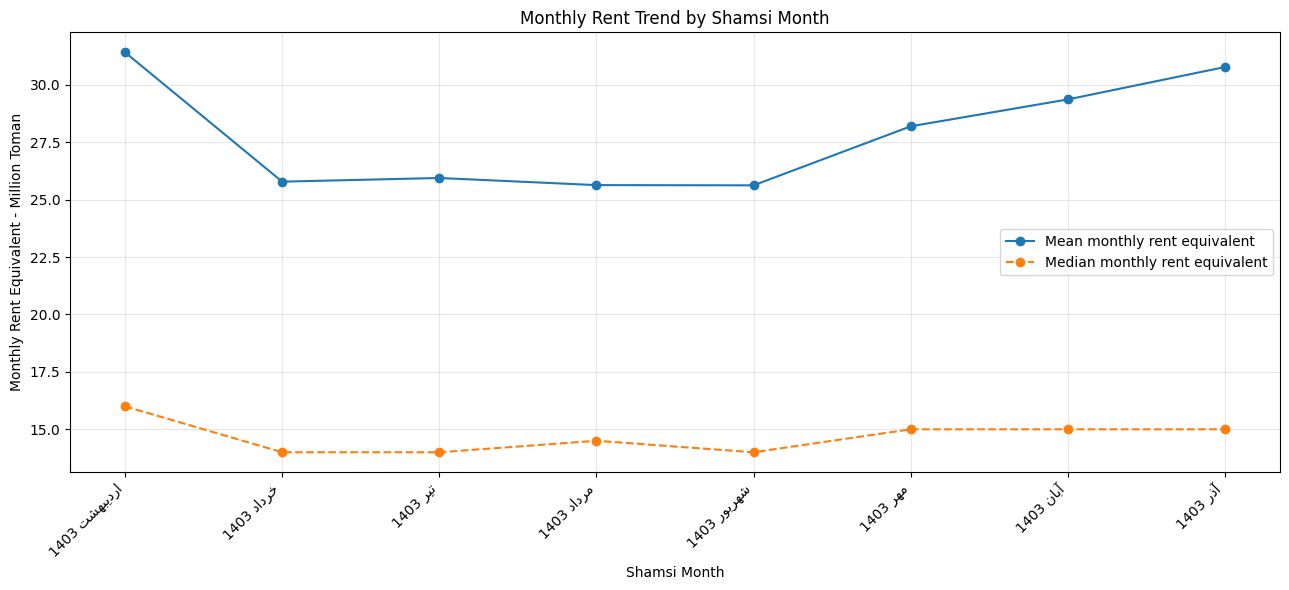

In [22]:
plot_rent_trend = reliable_monthly_rent_trend.copy()

plot_rent_trend["month_label"] = plot_rent_trend["created_at_shamsi_readable"].apply(fix_farsi_text)

x_positions = range(len(plot_rent_trend))

plt.figure(figsize=(13, 6))

plt.plot(
    x_positions,
    plot_rent_trend["mean_rent_million"],
    marker="o",
    label="Mean monthly rent equivalent"
)

plt.plot(
    x_positions,
    plot_rent_trend["median_rent_million"],
    marker="o",
    linestyle="--",
    label="Median monthly rent equivalent"
)

plt.title("Monthly Rent Trend by Shamsi Month")
plt.xlabel("Shamsi Month")
plt.ylabel("Monthly Rent Equivalent - Million Toman")

plt.xticks(
    ticks=x_positions,
    labels=plot_rent_trend["month_label"],
    rotation=45,
    ha="right"
)

plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

<div dir="rtl" style="text-align: right;">

## تحلیل نهایی سؤال ۶

در این بخش روند میانگین اجاره معادل ماهانه بر اساس ماه‌های شمسی بررسی شد. برای این تحلیل فقط آگهی‌های اجاره‌ای معتبر انتخاب شدند و از ستون <code>monthly_rent_equivalent</code> استفاده شد. این ستون مناسب‌تر از اجاره خام است، چون مبلغ رهن را نیز به اجاره ماهانه معادل تبدیل می‌کند.

در داده‌ی اولیه، بعضی ماه‌ها تعداد آگهی بسیار کمی داشتند؛ برای مثال برخی ماه‌های سال ۱۴۰۱ و ۱۴۰۲ فقط چند آگهی داشتند. این ماه‌ها نمی‌توانند نماینده‌ی قابل اعتمادی از بازار اجاره باشند. بنابراین برای نمودار اصلی فقط ماه‌هایی استفاده شدند که حداقل ۱۰۰۰ آگهی معتبر اجاره داشتند.

بر اساس جدول نهایی، بازه‌ی قابل اعتماد تحلیل از اردیبهشت ۱۴۰۳ تا آذر ۱۴۰۳ است. در اردیبهشت ۱۴۰۳ میانگین اجاره معادل ماهانه حدود ۳۱.۴۱ میلیون تومان بوده است. سپس در خرداد تا شهریور ۱۴۰۳ میانگین اجاره در محدوده‌ی حدود ۲۵ تا ۲۶ میلیون تومان قرار گرفته است.

از مهر ۱۴۰۳ به بعد، میانگین اجاره دوباره روند افزایشی پیدا کرده و از حدود ۲۸.۱۹ میلیون تومان در مهر به حدود ۳۰.۷۷ میلیون تومان در آذر رسیده است. بنابراین در بازه‌ی قابل اعتماد داده‌ها، ابتدا کاهش نسبت به اردیبهشت دیده می‌شود و سپس از مهر تا آذر روند افزایشی مشاهده می‌شود.

میانه‌ی اجاره در این دوره نسبتاً پایدارتر از میانگین است و بیشتر در بازه‌ی ۱۴ تا ۱۵ میلیون تومان قرار دارد. اختلاف زیاد میانگین و میانه نشان می‌دهد توزیع اجاره راست‌چوله است؛ یعنی بیشتر آگهی‌ها در بازه‌های پایین‌تر قرار دارند، اما تعدادی آگهی با اجاره‌های بسیار بالا باعث افزایش میانگین شده‌اند.

در مجموع، بازار اجاره در داده‌های معتبر سال ۱۴۰۳ نوسان دارد، اما از مهر تا آذر افزایش تدریجی در میانگین اجاره معادل ماهانه دیده می‌شود.

</div>